<hr style="height:10px"> 
 
<div class='container2'>
		<div>
			<img src='img_livro.png' ALIGN='left' style='width:10em'>
		</div>	
	<div style='padding: 0 7em 2em 12em;'>
	<h1>Inteligência Artificial: Uma Abordagem de Aprendizado de Máquina</h1>
    <h3> <a href="http://lattes.cnpq.br/4451540730749377">Katti Faceli</a> &#x25CF; <a href="http://lattes.cnpq.br/3451628262694747">Ana C. Lorena</a> &#x25CF; <a href="https://scholar.google.com/citations?user=jjoTZfoAAAAJ&hl=en">João Gama</a> &#x25CF; <a href="http://lattes.cnpq.br/5368680512020633">Tiago A. Almeida</a> &#x25CF; <a href="http://lattes.cnpq.br/9674541381385819">André C. P. L. F. de Carvalho</a></h3><br>
	<div style="font-size:12pt;float:left;"><b>Edição:</b> 2/2021 | <b>Editora:</b> LTC</div><br><br>
    <div style="font-size:12pt;float:left;"><b>Copyright &copy; 2021 LTC Editora. Todos os direitos reservados.</b></div>
	</div>
</div>


 <hr style="height:5px"> 

    
<h2>Categorização de Textos</h2>

Notebook desenvolvido por: <a href="http://lattes.cnpq.br/2532893661927339">Renato Moraes Silva</a>

 <hr style="height:2px"> 

## Introdução

Neste notebook, será apresentado como realizar classificação de textos. O primeiro exemplo de aplicação será um filtro de SMS spam. Mensagens de texto são consideradas spam quando enviadas sem terem sido solicitadas ou desejadas pelos usuários. Normalmente, elas são usadas para propagandas ou aplicação de fraudes [1]. O segundo exemplo de aplicação será um detector de notícias falsas (*fake news*). Esse tipo de notícia é produzido intencionalmente com o propósito de enganar as pessoas, podendo ser bastante prejudicial, pois pode influenciar opiniões políticas, prejudicar a imagem de pessoas ou instituições e até mesmo causar danos para a saúde pública [2]. 

O método naive Bayes multinomial [3] será usado para fazer a classificação dos documentos nas duas aplicações. Ao final do notebook, é esperado que o leitor tenha assimilado as principais etapas necessárias para a classificação de texto, incluindo o pré-processamento (*e.g.*, deixar todas as palavras com letras minúsculas, tratar URLs, emails e outros termos especiais, remover *stopwords* e aplicar estemização), a conversão do texto em uma representação adequada e o treinamento de um método de classificação.

Este notebook se refere ao **Capítulo 23 (Categorização de Textos)**.

---
## Recursos Necessários

Para este notebook, deve ser utilizado o `Python 3.5` ou superior com as seguintes bibliotecas externas, que deverão ser instaladas:

* [`matplotlib`](https://matplotlib.org/3.1.1/index.html)  (versão 3.1.3 ou superior): construção e exibição de gráficos variados
* [`numpy`](https://numpy.org) (versão 1.16.2 ou superior): manipulação de dados em formato de vetores e matrizes
* [`pandas`](https://pandas.pydata.org/pandas-docs/stable/index.html) (versão 0.24.1 ou superior): manipulação de dados em formato de tabelas
* [`scikit-learn`](https://scikit-learn.org/stable/) (versão 0.22.1 ou superior): conjunto de métodos e modelos úteis para Aprendizado de Máquina e Inteligência Artificial
* [`nltk`](https://www.nltk.org/) (versão 3.4.5 ou superior): conjunto de métodos, bases de dados e modelos úteis para Processamento de Linguagem Natural
* [`wordcloud`](https://pypi.org/project/wordcloud/) (versão 1.5.0 ou superior): geração de nuvens de palavras

Para que alguns módulos da biblioteca [NLTK](https://www.nltk.org/) possam ser executados, é necessário fazer o download das bases de dados e pacotes complementares usados pela biblioteca, usando o script `nltk.download('all')`. 

As bibliotecas [os](https://docs.python.org/3/library/os.html) (usada para realizar tarefas específicas ao Sistema Operacional) e [unicodedata](https://docs.python.org/3/library/unicodedata.html) (oferece funções relacionadas ao padrão Unicode) também serão utilizadas. Por fazerem parte da biblioteca padrão de [Python](https://docs.python.org/pt-br/3/library/), sua instalação não é necessária.


Serão utilizados também os conjuntos de dados disponibilizados no diretório `datasets`.

---
## Filtro de SMS Spam

Primeiro, vamos importar todas as bibliotecas que serão usadas ao longo deste notebook.

In [1]:
# -*- coding: utf-8 -*-

import numpy as np # biblioteca usada para trabalhar com vetores e matrizes
import pandas as pd # biblioteca usada para trabalhar com dataframes e análise de dados
import sklearn as skl # sckit-learn
import time # biblioteca usada para calcular o tempo de execucao
import re # biblioteca para expressoes regulares
import os # biblioteca usada para realizar tarefas específicas ao SO

# importa alguns pacotes do sckit-learn
from sklearn import model_selection 
from sklearn import naive_bayes # necessario para usar o metodo naive Bayes
from sklearn import model_selection # necessario para fazer validacao cruzada
from sklearn import metrics # necessario para obter o desempenho da classificacao

import nltk # biblioteca para Processamento de Linguagem Natural
from nltk.stem.porter import PorterStemmer # para fazer a estemização em documentos da lingua inglesa
from nltk.stem import RSLPStemmer # para fazer a estemização em documentos da lingua portuguesa
#nltk.download('all') # instala todos os recursos da biblioteca NLTK. Você pode descomentar esta linha na 1a vez que for executar este notebook

import unicodedata # sera usada para remover acentos dos documentos em lingua portuguesa

# bibliotecas para geração de gráficos
import matplotlib.pyplot as plt

from wordcloud import WordCloud # gera nuvens de palavras

# executa o arquivo que contém funções auxiliares que serao usadas neste exercício
%run utils.py

print('Bibliotecas carregadas com sucesso')

Bibliotecas carregadas com sucesso


## Exemplos de mensagens

Abaixo são mostrados alguns exemplos de SMS legítimos:
 * ```Is that seriously how you spell his name?```
 * ```What you thinked about me. First time you saw me in class.```
 * ```Ok lar i double check wif da hair dresser already he said wun cut v short. He said will cut until i look nice.```
 
Abaixo são mostrados alguns exemplos de SMS spam:
 * ```WINNER!! As a valued network customer you have been selected to receivea £900 prize reward! To claim call 09061701461. Claim code KL341. Valid 12 hours only.```
 * ```Thanks for your subscription to Ringtone UK your mobile will be charged £5/month Please confirm by replying YES or NO. If you reply NO you will not be charged.```
 * ```Congratulations ur awarded 500 of CD vouchers or 125gift guaranteed & Free entry 2 100 wkly draw txt MUSIC to 87066 TnCs http://www.Ldew.com1win150ppmx3age16.```

Dentro da pasta *datasets*, há uma base de dados de SMS. Essa base foi proposta por Almeida *et. al.* [1] e pode ser encontrada no seguinte link: <https://archive.ics.uci.edu/ml/datasets/SMS+Spam+Collection>. 

Vamos importar a base de dados. 

In [2]:
def import_dataset(pathDataset):
    """
    Função usada para importar a base de dados textual
    
    Parametros:
    -----------
    pathDataset: string
        Endereço da base de dados. Cada linha da base de dados, deve ter o formato <classe, mensagem>.        
    """
     
    datasetFile = open(pathDataset,'r') # abre o arquivo para leitura
    
    dataset = [] # lista vazia que irá guardar as mensagens
    target = []
    for line in datasetFile:
        splitLine = line.split(',')
        
        classe = splitLine[0] 
        texto = ' '.join(splitLine[1::])
        
        target.append(classe)
        dataset.append(texto)
    
    target = np.asarray(target) # converte a lista para um array do numpy
    dataset = np.asarray(dataset) # converte a lista para um array do numpy
        
    return dataset, target

# importa a base de dados
dataset, target = import_dataset('datasets/SMSSpamCollection.txt')

print('5 primeiras amostras: \n')
print(dataset[0:5])

classes = np.unique(target)
print('\nClasses: ', classes)

5 primeiras amostras: 

['Go until jurong point  crazy.. Available only in bugis n great world la e buffet... Cine there got amore wat...\n'
 'Ok lar... Joking wif u oni...\n'
 "Free entry in 2 a wkly comp to win FA Cup final tkts 21st May 2005. Text FA to 87121 to receive entry question(std txt rate)T&C's apply 08452810075over18's\n"
 'U dun say so early hor... U c already then say...\n'
 "Nah I don't think he goes to usf  he lives around here though\n"]

Classes:  ['ham' 'spam']


Vamos dividir os dados em treino e teste de forma estratificada. Iremos usar a validação *holdout* estratificada por motivos didáticos. No entanto, sempre que for possível, é mais recomendado usar a validação cruzada K-fold, pois é mais robusta.

In [3]:
# gera uma divisão dos dados em treino e teste
cv = skl.model_selection.StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=2019)

# retorna os índices de treino e teste
train_index, test_index = list( cv.split(dataset, target) )[0]

# retorna as partições de treino e teste de acordo com os índices
dataset_train, dataset_test = dataset[train_index], dataset[test_index];
Y_train, Y_test = target[train_index], target[test_index];

print('Qtd. dados de treinamento: %d (%1.2f%%)' %(dataset_train.shape[0], (dataset_train.shape[0]/dataset.shape[0])*100) )
print('Qtd. de dados de teste: %d (%1.2f%%)' %(dataset_test.shape[0], (dataset_test.shape[0]/dataset.shape[0])*100) )

# imprime a porcentagem de dados de treinamento de cada classe
print("\nQtd. de dados de cada classe (treinamento)")
cTrain, counts_cTrain = np.unique(np.sort(Y_train), return_counts=True)
for i in range( len(cTrain) ):
    print('\tClasse %s: %d (%1.2f%%)' %( cTrain[i],counts_cTrain[i],(counts_cTrain[i]/len(Y_train))*100 ) )

# imprime a porcetagem de dados de teste de cada classe
print("\nQtd. de dados de cada classe (teste)")
cTest, counts_cTest = np.unique(np.sort(Y_test), return_counts=True)
for i in range( len(cTrain) ):
    print('\tClasse %s: %d (%1.2f%%)' %( cTest[i],counts_cTest[i],(counts_cTest[i]/len(Y_test))*100 ) )

Qtd. dados de treinamento: 3901 (69.99%)
Qtd. de dados de teste: 1673 (30.01%)

Qtd. de dados de cada classe (treinamento)
	Classe ham: 3378 (86.59%)
	Classe spam: 523 (13.41%)

Qtd. de dados de cada classe (teste)
	Classe ham: 1449 (86.61%)
	Classe spam: 224 (13.39%)


A primeira etapa no pipeline da classificação de textos, é realizar o pré-processamento das amostras. 

**Importante:** as técnicas de tratamento de texto que iremos aplicar nesse exercício não são as únicas. Além disso, uma técnica pode ajudar a classificação em um determinado problema e não ajudar ou até mesmo atrapalhar a classificação em outro problema. 


Na função abaixo, os seguintes pré-processamentos são realizados:

 - deixar todas as palavras com letras minúsculas
 - substituir os números pela tag *\<NUMBER\>*
 - substituir todas as URLS pela tag *\<URL\>*
 - substiuir todos os emails pela tag *\<EMAIL\>*
 - substituir o símbolo de moeda pela tag *\<MONEY\>*
 - substituir todos os caracteres não-alfanuméricos por um espaço em branco
 
Além dos pré-processamentos apresentados acima, também podemos aplicar *estemização*. A estemização diminui as palavras para seus radicais. Veja como fica algumas palavras após a estemização: 
 - *flies* é substituída por *fli*
 - *sensational* é substituída por *sensat*
 - *plotted* é subsituída por *plot*
 
Além da estemização, também é comum fazer a remoção de palavras muito comuns da língua, as chamadas *stopwords*. 
 
Para aplicar a estemização e remover as stopwords, iremos usar a biblioteca [NLTK](https://www.nltk.org/). Para que a função de estemização e remoção de *stopwords* funcionem, você precisa instalar a biblioteca e fazer o download dos seus pacotes, usando o script `nltk.download('all')`. 
 
Por fim, também é recomendado eliminar todas as palavras muito curtas. Vamos eliminar qualquer palavra de apenas um caracter. 

In [4]:
def preprocessing(text, stemming = False, stopwords = False):
    """
    Funcao usada para fazer o tratamento de textos da lingua inglesa
    
    Parametros: 
        text: variavel do tipo string que contem o texto que devera ser tratado
        
        stemming: variavel do tipo booleana que indica se a estemizacao deve ser aplicada ou nao
        
        stopwords: variavel do tipo booleana que indica se as stopwords devem ser removidas ou nao
    """
    
    # Lower case
    text = text.lower()
    
    # remove tags HTML
    regex = re.compile('<[^<>]+>')
    text = re.sub(regex, " ", text) 
    
    # normaliza as URLs
    regex = re.compile('(http|https)://[^\s]*')
    text = re.sub(regex, "<URL>", text)

    # normaliza emails
    regex = re.compile('[^\s]+@[^\s]+')
    text = re.sub(regex, "<EMAIL>", text)
    
    #normaliza o símbolo de dólar
    regex = re.compile('[$]+')
    text = re.sub(regex, "<MONEY>", text)
    
    # converte todos os caracteres não-alfanuméricos em espaço
    regex = re.compile('[^A-Za-z0-9]+')  
    text = re.sub(regex, " ", text)
    
    # normaliza os numeros 
    regex = re.compile('[0-9]+')
    text = re.sub(regex, "<NUMBER>", text)
    
    # substitui varios espaçamentos seguidos em um só
    text = ' '.join(text.split())

    # remove stopwords
    if stopwords:
        words = text.split() # separa o texto em palavras
        words = [w for w in words if not w in nltk.corpus.stopwords.words('english')]
        text = " ".join( words )
    
    # aplica estemização
    if stemming: 
        stemmer_method = PorterStemmer()  
        words = text.split() # separa o texto em palavras
        words = [ stemmer_method.stem(w) for w in words ]
        text = " ".join( words )
    
    # remove palavras de apenas um caracter
    words = text.split() # separa o texto em palavras
    words = [ w for w in words if len(w)>1 ]
    text = " ".join( words )
    
    return text

smsContent = 'Congratulations ur awarded 500 of CD vouchers or 125gift guaranteed & Free entry 2 100 wkly draw txt MUSIC to 87066 TnCs http://www.Ldew.com1win150ppmx3age16.'
print('Antes do preprocessamento: \n', smsContent)

# chama a função de pré-processsamento para tratar a amostra
smsContent = preprocessing(smsContent, stemming = True, stopwords = True)

print('\nDepois do preprocessamento: \n', smsContent)

Antes do preprocessamento: 
 Congratulations ur awarded 500 of CD vouchers or 125gift guaranteed & Free entry 2 100 wkly draw txt MUSIC to 87066 TnCs http://www.Ldew.com1win150ppmx3age16.

Depois do preprocessamento: 
 congratul ur award <number> cd voucher <number>gift guarante free entri <number> <number> wkli draw txt music <number> tnc url


Aplica o pré-processamento nos dados de treinamento e de teste. 

In [5]:
# aplica o pre-processamento dos dados de treinamento
print('Qtd. de documentos de treinamento tratados: ')
for i, msg in enumerate(dataset_train):
    dataset_train[i] = preprocessing(dataset_train[i], stemming = True, stopwords = True)

    if i%50==0 or i==len(dataset_train)-1:
        print(' %d de %d' %(i+1, len(dataset_train)), end='\r')
        
print('\n\nPrimeira mensagem de treinamento apos o pre-processamento: \n\t', dataset_train[0])
    
# aplica o pre-processamento dos dados de teste
print('\n\n\nQtd. de documentos de teste tratados: ')
for i, msg in enumerate(dataset_test):
    dataset_test[i] = preprocessing(dataset_test[i], stemming = True, stopwords = True)

    if i%50==0 or i==len(dataset_test)-1:
        print(' %d de %d' %(i+1, len(dataset_test)), end='\r')
    
print('\n\nPrimeira mensagem de teste apos o pre-processamento: \n\t', dataset_test[0])

Qtd. de documentos de treinamento tratados: 
 3901 de 3901

Primeira mensagem de treinamento apos o pre-processamento: 
	 hope settl new school year wishin gr<number> day



Qtd. de documentos de teste tratados: 
 1673 de 1673

Primeira mensagem de teste apos o pre-processamento: 
	 import custom servic announc call freephon <number> <number> <number>


Para uma melhor visualização dos dados de treinamento após o pré-processamento, vamos gerar uma nuvem de palavras para cada classe do problema.

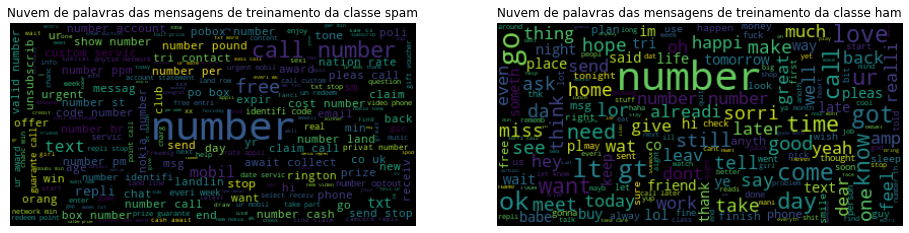

In [6]:
def plot_cloud(text, ax, title):
    
    # gera a nuvem de palavras
    wordcloud = WordCloud().generate(text)
    
    # calcula frequencia relativa das palavras
    wordcloud = WordCloud(max_font_size=40, relative_scaling=.5).generate(text)
    ax.imshow(wordcloud, interpolation='bilinear')
    ax.axis("off")
    ax.set_title(title, fontsize='large')
    
# define a quantidade de linhas e colunas e o tamanho da figura
nrows = 1; ncols=2; 
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8*ncols, 8*nrows))

# junta todas as mensagens da classe spam em uma unica string
text_spam = " ".join(dataset_train[ Y_train=='spam' ])

# gera a nuvem de palavras e plota
plot_cloud(text_spam, axs[0], 'Nuvem de palavras das mensagens de treinamento da classe spam')

# junta todas as mensagens da classe ham em uma unica string
text_ham = " ".join(dataset_train[ Y_train=='ham' ])

# gera a nuvem de palavras e plota
plot_cloud(text_ham, axs[1], 'Nuvem de palavras das mensagens de treinamento da classe ham')


Depois de fazer o pré-processamento, é necessário transformar o texto em um vetor de atributos com valores numéricos. Uma das formas de fazer isso é considerar que cada palavra (ou token) da base de dados de treinamento é um atributo que armazena o número de vezes que uma determinada palavra aparece no texto. Na biblioteca `scikit-learn` podemos fazer essa conversão de texto para um vetor de atributos usando a função `skl.feature_extraction.text.CountVectorizer()`. Essa função gera um modelo de vetorização que pode ser ajustado com a base nos dados de treinamento usando a função `fit_transform()`.

In [7]:
# inicializa o modelo usado para gerar a representação TF (term frequency)
vectorizer = skl.feature_extraction.text.CountVectorizer(analyzer = "word", tokenizer = None, preprocessor = None, stop_words = None, lowercase = True, binary=False, dtype=np.int32)

# treina o modelo TF com os dados de treinamento e converte os dados de treinamento para uma array que contém a frequência dos termos em cada documento (TF - term frequency)
X_train = vectorizer.fit_transform(dataset_train) 

print('20 primeiras palavras do vocabulário obtido a partir dos dados de treinamento:\n')
print(vectorizer.get_feature_names()[0:20])

print('\nDimensão dos dados de treinamento vetorizados: ', X_train.shape)

# converte os dados de teste para um array que contém a frequência dos termos em cada documento (TF - term frequency)
X_test = vectorizer.transform(dataset_test) # converte os dados de teste, usando o modelo gerado pelos dados de treinamento 
print('\nDimensão dos dados de teste vetorizados: ', X_test.shape)

20 primeiras palavras do vocabulário obtido a partir dos dados de treinamento:

['aa', 'aah', 'aaniy', 'aathi', 'ab', 'abbey', 'abdomen', 'abeg', 'abel', 'abi', 'abil', 'abiola', 'abj', 'abl', 'abnorm', 'abroad', 'absenc', 'absolut', 'absolutli', 'abstract']

Dimensão dos dados de treinamento vetorizados:  (3901, 5299)

Dimensão dos dados de teste vetorizados:  (1673, 5299)


Como os dados de treinamento e teste já estão vetorizados, podemos usá-los para treinar e testar qualquer método de classificação. Vamos usar o *naive* Bayes multinomial. Para obter informações sobre esse método de classificação, consulte o Capítulo 5 (Métodos Probabilísticos).

In [8]:
# carrega o classificador
NBclassifier = skl.naive_bayes.MultinomialNB() 

# treina o classificador com os dados de treinameto
NBclassifier.fit(X_train, Y_train) 
 
# classifica os dados de teste
Y_pred = NBclassifier.predict(X_test) 
        
print('\nPredição obtida para as 20 primeiras amostras de teste:\n', Y_pred[0:20])


Predição obtida para as 20 primeiras amostras de teste:
 ['spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham' 'spam'
 'ham' 'spam' 'ham' 'ham' 'ham' 'ham' 'ham' 'ham']


Vamos imprimir o relatório de desempenho da classificação usando a função auxiliar `relatorioDesempenho()` que se encontra no arquivo `utils.py`.

In [9]:
# obtem as medidas de desempenho
resultados = relatorioDesempenho(Y_test, Y_pred, classes, imprimeRelatorio=True)


	Revocacao   Precisao   F-medida   Classe
	0.992       0.995      0.994      ham
	0.969       0.952      0.960      spam
	------------------------------------------------
	0.981       0.973      0.977      Média macro
	0.989       0.989      0.989      Média micro

	Acuracia: 0.989


Também, podemos testar o classificador em uma nova mensagem de texto. Por exemplo, vamos testá-lo no seguinte exemplo de SMS: *'URGENT! We are trying to contact U because you have won a 1000 prize GUARANTEED. Call 08000920123 now.'*

In [10]:
smsContent = 'URGENT! We are trying to contact U because you have won a 1000 prize GUARANTEED. Call 08000920123 now.'

print('\nMensagem original:')
print(smsContent) 

# chama a função de pré-processsamento para tratar a mensagem
smsContent = preprocessing(smsContent, stemming = True, stopwords = True)

print('\nMensagem tratada:')
print(smsContent)

# converte o texto para um vetor de atributos
smsVec = vectorizer.transform([smsContent]) 

print('Dimensão da mensagem vetorizada: ', smsVec.shape)

# classifica a amostra
classe = NBclassifier.predict(smsVec) 

print('\nClasse predita pelo classificador: ', classe)


Mensagem original:
URGENT! We are trying to contact U because you have won a 1000 prize GUARANTEED. Call 08000920123 now.

Mensagem tratada:
urgent tri contact <number> prize guarante call <number>
Dimensão da mensagem vetorizada:  (1, 5299)

Classe predita pelo classificador:  ['spam']


---
## Classificação de Notícias Falsas

Nesta parte do notebook, usaremos o *naive* Bayes multinomial para classificar notícias falsas (*fake news*).

Veja um exemplo de notícia falsa:
 * ```Polos magnéticos da Terra podem se inverter e causar colapso mundial: "A Terra ficaria inabitável". Aos menos 100 mil pessoas morreriam por ano pela alta nos níveis de radiação espacial." Se o campo magnético continuar a diminuir e os polos magnéticos se inverterem, a Terra pode acabar como Marte – um local seco, árido e incapaz de preservar a vida.```
 
Exemplo de notícia verdadeira:
 * ```Inversão dos polos magnéticos da Terra pode ocorrer mais rápido do que o previsto. Segundo afirmações, essas ocorrências são, a princípio, indistinguíveis das verdadeiras mudanças nos polos. Apesar dessas reversões não representarem qualquer ameaça à humanidade, os especialistas alertam que poderão gerar falhas nos satélites que orbitam a Terra.```
 
 
Dentro da pasta `datasets`, há uma base de dados de notícias falsas. Essa base foi proposta por Monteiro *et. al.* [2] e pode ser encontrada no seguinte link: <https://github.com/roneysco/Fake.br-Corpus>.
 
Primeiro, vamos importar os dados da base.

In [11]:
def import_fakeNewsDataset(path):

    files = os.listdir(path)
    
    dataset = []

    for i, file in enumerate(files):
        # abre o arquivo
        fileTexto = open(path+'/'+file, "r", encoding='utf8', errors='replace') #utf8 #cp1252
        
        # le o arquivo e armazena o texto dentro da variavel "texto"
        texto = fileTexto.read()

        dataset.append(texto)

    return dataset

# importa a base de dados de noticias falsas
dataset_fake = import_fakeNewsDataset('datasets/Fake.br-Corpus-master/full_texts/fake/')
print('Noticias falsas importadas com sucesso')

# cria um vetor de 1 para indicar a classe de cada noticia falsa
target_fake = np.ones( len(dataset_fake), dtype=int )


# importa a base de dados de noticias falsas
dataset_true = import_fakeNewsDataset('datasets/Fake.br-Corpus-master/full_texts/true/')
print('Noticias verdadeiras importadas com sucesso')

# cria um vetor de 0 para indicar a classe de cada noticia verdadeira
target_true = np.zeros( len(dataset_true), dtype=int )

# concatena as noticias verdadeiras e falsas
dataset2 = np.asarray( dataset_fake+dataset_true )

# concatena os vetores de classes das notícias verdadeiras e falsas
target2 = np.concatenate((target_fake,target_true))

# obtem as classes do problema
classes2 = np.unique(target2)

print('\nQtd. de noticias falsas: %d' %len(dataset_fake))
print('Qtd. de noticias verdadeiras: %d' %len(dataset_true))

Noticias falsas importadas com sucesso
Noticias verdadeiras importadas com sucesso

Qtd. de noticias falsas: 3600
Qtd. de noticias verdadeiras: 3600


Agora, vamos tratar os textos importados da base de dados. Como as notícias foram escritas em língua portuguesa, devemos usar uma função de estemização apropriada para a língua portuguesa. Iremos também remover os acentos das palavras. 

Outro ponto importante é que as notícias verdadeiras em geral são mais longas que as notícias falsas. Então, para evitar que a predição do classificador seja mais influenciada pelo tamanho da notícia do que pelo conteúdo, na função de pré-processamento, o texto será truncado para apenas 200 termos. 

**Obs.**: neste exercício não iremos remover as *stopwords*, pois pode levar um tempo considerável para executar. No entanto, caso o leitor deseje executar essa etapa, basta setar o parâmetro `stopwords` da função `preprocessing_portuguese()` para o valor `True`.

In [12]:
def preprocessing_portuguese(text, stemming = False, stopwords = False):
    """
    Funcao usada para tratar textos escritos na lingua portuguesa
    
    Parametros: 
        text: variavel do tipo string que contem o texto que devera ser tratado
        
        stemming: variavel do tipo boolean que indica se a estemizacao deve ser aplicada ou nao
        
        stopwords: variavel do tipo boolean que indica se as stopwords devem ser removidas ou nao
    """
    
    # Lower case
    text = text.lower()
    
    # remove os acentos das palavras
    nfkd_form = unicodedata.normalize('NFKD', text)
    text = u"".join([c for c in nfkd_form if not unicodedata.combining(c)])
    
    # remove tags HTML
    regex = re.compile('<[^<>]+>')
    text = re.sub(regex, " ", text) 
    
    # normaliza as URLs
    regex = re.compile('(http|https)://[^\s]*')
    text = re.sub(regex, "<URL>", text)

    # normaliza emails
    regex = re.compile('[^\s]+@[^\s]+')
    text = re.sub(regex, "<EMAIL>", text)
    
    # converte todos os caracteres não-alfanuméricos em espaço
    regex = re.compile('[^A-Za-z0-9]+') 
    text = re.sub(regex, " ", text)
    
    # normaliza os numeros 
    regex = re.compile('[0-9]+')
    text = re.sub(regex, "<NUMERO>", text)
    
    # substitui varios espaçamentos seguidos em um só
    text = ' '.join(text.split())

    # separa o texto em palavras
    words = text.split() 
        
    # trunca o texto para apenas 200 termos
    words = words[0:200]

    # remove stopwords
    if stopwords:
        words = text.split() # separa o texto em palavras
        words = [w for w in words if not w in nltk.corpus.stopwords.words('portuguese')]
        text = " ".join( words )
    
    # aplica estemização
    if stemming: 
        stemmer_method = RSLPStemmer()
        words = [ stemmer_method.stem(w) for w in words ]
        text = " ".join( words )

    # remove palavras compostas por apenas um caracter
    words = text.split() # separa o texto em palavras
    words = [ w for w in words if len(w)>1 ]
    text = " ".join( words )
    
    return text

exemplo_noticia = 'Polos magnéticos da Terra podem se inverter e causar colapso mundial: "A Terra ficaria inabitável". Aos menos 100 mil pessoas morreriam por ano pela alta nos níveis de radiação espacial." Se o campo magnético continuar a diminuir e os polos magnéticos se inverterem, a Terra pode acabar como Marte – um local seco, árido e incapaz de preservar a vida.'
print('Antes do preprocessamento: \n', exemplo_noticia)

# executa a função de pré-processsamento para tratar a amostra de texto
exemplo_noticia = preprocessing_portuguese(exemplo_noticia, stemming = True, stopwords = False)

print('\nDepois do preprocessamento: \n', exemplo_noticia)

Antes do preprocessamento: 
 Polos magnéticos da Terra podem se inverter e causar colapso mundial: "A Terra ficaria inabitável". Aos menos 100 mil pessoas morreriam por ano pela alta nos níveis de radiação espacial." Se o campo magnético continuar a diminuir e os polos magnéticos se inverterem, a Terra pode acabar como Marte – um local seco, árido e incapaz de preservar a vida.

Depois do preprocessamento: 
 pol magne da terr pod se invert caus colaps mund terr fic inabita ao menos <numero> mil pesso morr por ano pel alt no nivel de radiaca espac se camp magne continu diminu os pol magne se invert terr pod acab com mart um local sec arid incapaz de preserv vid


Agora, vamos dividir os dados em treino e teste de forma estratificada. Usaremos novamente a validação *holdout* estratificada por motivos didáticos. No entanto, sempre que for possível, é mais recomendado usar a validação cruzada K-fold, pois é mais robusta. Para maiores detalhes, consulte o Capítulo 10 (Avaliação de Modelos Preditivos).

In [13]:
# divide os dados em treino e teste
cv2 = skl.model_selection.StratifiedShuffleSplit(n_splits=1, test_size=0.3, random_state=2019)

# retorna os índices de treino e teste
train_index2, test_index2 = list( cv2.split(dataset2, target2) )[0]

# retorna as partições de treino e teste de acordo com os índices
dataset2_train, dataset2_test = dataset2[train_index2], dataset2[test_index2];
Y2_train, Y2_test = target2[train_index2], target2[test_index2];

print('Qtd. dados de treinamento: %d (%1.2f%%)' %(dataset2_train.shape[0], (dataset2_train.shape[0]/dataset2.shape[0])*100) )
print('Qtd. de dados de teste: %d (%1.2f%%)' %(dataset2_test.shape[0], (dataset2_test.shape[0]/dataset2.shape[0])*100) )

# imprime a porcentagem de dados de treinamento de cada classe
print("\nQtd. de dados de cada classe (treinamento)")
cTrain, counts_cTrain = np.unique(np.sort(Y2_train), return_counts=True)
for i in range( len(cTrain) ):
    print('\tClasse %s: %d (%1.2f%%)' %( cTrain[i],counts_cTrain[i],(counts_cTrain[i]/len(Y2_train))*100 ) )

# imprime a porcentagem de dados de teste de cada classe
print("\nQtd. de dados de cada classe (teste)")
cTest, counts_cTest = np.unique(np.sort(Y2_test), return_counts=True)
for i in range( len(cTrain) ):
    print('\tClasse %s: %d (%1.2f%%)' %( cTest[i],counts_cTest[i],(counts_cTest[i]/len(Y2_test))*100 ) )

Qtd. dados de treinamento: 5040 (70.00%)
Qtd. de dados de teste: 2160 (30.00%)

Qtd. de dados de cada classe (treinamento)
	Classe 0: 2520 (50.00%)
	Classe 1: 2520 (50.00%)

Qtd. de dados de cada classe (teste)
	Classe 0: 1080 (50.00%)
	Classe 1: 1080 (50.00%)


Aplica o pré-processamento nos dados de treinamento e de teste.

In [14]:
# aplica o pre-processamento nos dados de treinamento
print('Qtd. de documentos de treinamento tratados: ')
for i, msg in enumerate(dataset2_train):  
    dataset2_train[i] = preprocessing_portuguese(dataset2_train[i], stemming = True, stopwords = False)
    
    if i%50==0 or i==len(dataset2_train)-1:
        print(' %d de %d' %(i+1, len(dataset2_train)), end='\r')
    
print('\n\nPrimeira mensagem de treinamento apos o pre-processamento:')
print('\n%s\n%s\n%s\n' %(50*'-',dataset2_train[10],50*'-'))

# aplica o pre-processamento nos dados de teste
print('Qtd. de documentos de teste tratados: ')
for i, msg in enumerate(dataset2_test):
    dataset2_test[i] = preprocessing_portuguese(dataset2_test[i], stemming = True, stopwords = False)
    
    if i%50==0 or i==len(dataset2_test)-1:
        print(' %d de %d' %(i+1, len(dataset2_test)), end='\r')
    
print('\n\nPrimeira mensagem de teste apos o pre-processamento:')
print('\n%s\n%s\n%s\n' %(50*'-',dataset2_test[10],50*'-'))

Qtd. de documentos de treinamento tratados: 
 5040 de 5040

Primeira mensagem de treinamento apos o pre-processamento:

--------------------------------------------------
quadr de saud de maris estavel ela fic na uti par observaca lul diss que est esperanc siri liban inform que don maris letic foi imediat submet um atend de emergenc segu de cirurg endovascul embolizaca oclusa do aneurism ela dev fic na uti por temp indetermin medic da famil dr kalil robert filh diss que quadr de saud de don maris estavel mas que ela aind corr risc de mort presid do institut lul inform que tud corr bem dur cirurg okamot inform que lul est preocup muit esperanc lul aind nao fal com imprens
--------------------------------------------------

Qtd. de documentos de teste tratados: 
 2160 de 2160

Primeira mensagem de teste apos o pre-processamento:

--------------------------------------------------
joaquim barb defend eleico diret nao descart candidat ex presid do stf supr tribun feder joaquim barb diss ne

Para visualizar os dados de treinamento após o pré-processamento, vamos gerar uma nuvem de palavras para cada classe.  

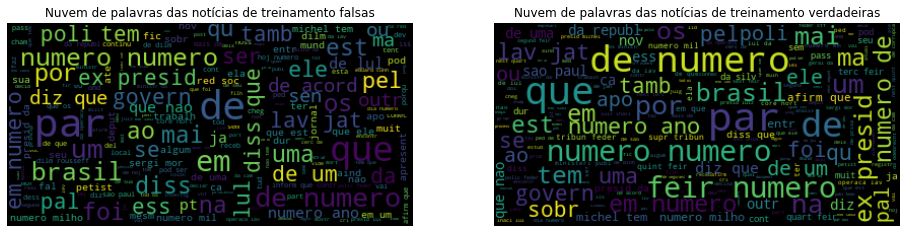

In [15]:
# define a quantidade de linhas e colunas e o tamanho da figura
nrows = 1; ncols=2; 
fig, axs = plt.subplots(nrows=nrows, ncols=ncols, figsize=(8*ncols, 8*nrows))

# junta todas as fake news em uma unica string
text_fake = " ".join(dataset2_train[ Y2_train==1 ])

# gera a nuvem de palavras e plota
plot_cloud(text_fake, axs[0], 'Nuvem de palavras das notícias de treinamento falsas')

# junta todas as noticias verdadeiras em uma unica string
text_true = " ".join(dataset2_train[ Y2_train==0 ])

# gera a nuvem de palavras e plota
plot_cloud(text_true, axs[1], 'Nuvem de palavras das notícias de treinamento verdadeiras')

Agora, vamos transformar o texto em um vetor de atributos com valores numéricos. Para obter maiores detalhes, consulte o Capítulo 23 (Categorização de Textos).

In [16]:
# inicializa o modelo usado para gerar a representação TF (term frequency)
vectorizer2 = skl.feature_extraction.text.CountVectorizer(analyzer = "word", tokenizer = None, preprocessor = None, stop_words = None, lowercase = True, binary=False, dtype=np.int32)

# treina o modelo TF com os dados de treinamento e converte os dados de treinamento para um array que contém a frequência dos termos em cada documento (TF - term frequency)
X2_train = vectorizer2.fit_transform(dataset2_train) 

print('20 primeiras palavras do vocabulário obtido a partir dos dados de treinamento:\n')
print(vectorizer2.get_feature_names()[0:20])

print('\nDimensão dos dados de treinamento vetorizados: ', X2_train.shape)

# converte os dados de teste para um array que contém a frequência dos termos em cada documento (TF - term frequency)
X2_test = vectorizer2.transform(dataset2_test) # converte os dados de teste, usando o modelo gerado pelos dados de treinamento 
print('\nDimensão dos dados de teste vetorizados: ', X2_test.shape)

20 primeiras palavras do vocabulário obtido a partir dos dados de treinamento:

['aa', 'aabb', 'aapes', 'aarhu', 'aaron', 'aashish', 'aba', 'abacax', 'abaf', 'abaix', 'abajur', 'abak', 'abal', 'aban', 'abandid', 'abandon', 'abarc', 'abarrot', 'abastec', 'abastecera']

Dimensão dos dados de treinamento vetorizados:  (5040, 17317)

Dimensão dos dados de teste vetorizados:  (2160, 17317)


Como os dados de treinamento e teste já estão vetorizados, podemos usá-los para treinar e testar qualquer método de classificação. Vamos usar o *naive* Bayes multinomial. Para obter informações sobre esse método de classificação, consulte o Capítulo 5 (Métodos Probabilísticos).

In [17]:
# carrega o classificador
NBclassifier2 = skl.naive_bayes.MultinomialNB() 

# treina o classificador com os dados de treinameto
NBclassifier2.fit(X2_train, Y2_train) 
 
# classifica os dados de teste
Y2_pred = NBclassifier2.predict(X2_test) 
        
print('\nPredição obtida para as 20 primeiras amostras de teste:\n', Y2_pred[0:20])


Predição obtida para as 20 primeiras amostras de teste:
 [0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 1 0 1 1 1]


Vamos imprimir o relatório de desempenho da classificação usando a função auxiliar `relatorioDesempenho()` que se encontra no arquivo `utils.py`.

In [18]:
# obtem as medidas de desempenho
resultados = relatorioDesempenho(Y2_test, Y2_pred, classes2, imprimeRelatorio=True)


	Revocacao   Precisao   F-medida   Classe
	0.864       0.823      0.843      0
	0.815       0.857      0.835      1
	------------------------------------------------
	0.839       0.840      0.839      Média macro
	0.839       0.839      0.839      Média micro

	Acuracia: 0.839


Agora, vamos testar o classificador no seguinte exemplo de notícia falsa: 
* ```AVISO IMPORTANTE : Olá, sou Laila Ahmadi da China, Faculdade de Ciências Médicas, Universidade de Zanjan. O vírus Corona chega a qualquer país mais cedo ou mais tarde, não há dúvida de que muitos países não possuem nenhum kit ou equipamento de diagnóstico; Por favor, use o máximo de * vitamina C natural possível * para fortalecer seu sistema imunológico. Atualmente, o vírus não contém vacina nem tratamento específico Infelizmente, devido à mutação genética que a tornou muito perigosa. Esta doença parece ser causada pela fusão do gene em uma cobra e um morcego, e adquiriu a capacidade de infectar mamíferos, incluindo humanos. É importante manter a mensagem de seu maior conhecimento: o professor Chen Horin, CEO do Hospital Militar de Pequim, disse: Fatias de limão em um copo de água morna podem salvar sua vida. * Mesmo se você estiver trabalhando, dê uma olhada nesta mensagem e passe para outras pessoas! Limão quente pode matar células cancerígenas! O limão cortado em três partes e colocado em um copo, depois despeje água quente e transforme-a em (água alcalina), beba todos os dias, definitivamente beneficiará a todos. Limões quentes podem liberar o medicamento anticâncer novamente. O suco de limão quente apareceu em tumores cancerígenos e curou todos os cânceres. O tratamento com esse extrato destrói apenas células malignas e não afeta células saudáveis. Segundo: os ácidos e o ácido carboxílico do suco de limão podem regular a pressão alta, proteger artérias estreitas, regular a circulação sanguínea e reduzir a coagulação do sangue.".```

In [19]:
noticiaExemplo = "AVISO IMPORTANTE : Olá, sou Laila Ahmadi da China, Faculdade de Ciências Médicas, Universidade de Zanjan. O vírus Corona chega a qualquer país mais cedo ou mais tarde, não há dúvida de que muitos países não possuem nenhum kit ou equipamento de diagnóstico; Por favor, use o máximo de * vitamina C natural possível * para fortalecer seu sistema imunológico. Atualmente, o vírus não contém vacina nem tratamento específico Infelizmente, devido à mutação genética que a tornou muito perigosa. Esta doença parece ser causada pela fusão do gene em uma cobra e um morcego, e adquiriu a capacidade de infectar mamíferos, incluindo humanos. É importante manter a mensagem de seu maior conhecimento: o professor Chen Horin, CEO do Hospital Militar de Pequim, disse: Fatias de limão em um copo de água morna podem salvar sua vida. * Mesmo se você estiver trabalhando, dê uma olhada nesta mensagem e passe para outras pessoas! Limão quente pode matar células cancerígenas! O limão cortado em três partes e colocado em um copo, depois despeje água quente e transforme-a em (água alcalina), beba todos os dias, definitivamente beneficiará a todos. Limões quentes podem liberar o medicamento anticâncer novamente. O suco de limão quente apareceu em tumores cancerígenos e curou todos os cânceres. O tratamento com esse extrato destrói apenas células malignas e não afeta células saudáveis. Segundo: os ácidos e o ácido carboxílico do suco de limão podem regular a pressão alta, proteger artérias estreitas, regular a circulação sanguínea e reduzir a coagulação do sangue."

print('\nNoticia original:')
print(noticiaExemplo) 

# chama a função de pré-processsamento para tratar a amostra
noticiaExemplo = preprocessing_portuguese(noticiaExemplo, stemming = True, stopwords = False)

print('\nNoticia tratada:')
print(noticiaExemplo)

# converte o texto para um vetor de features
noticiaExemploVec = vectorizer2.transform([noticiaExemplo]) 

print('\nDimensão da noticia vetorizada: ', noticiaExemploVec.shape)

# classifica a amostra
classe = NBclassifier2.predict(noticiaExemploVec) 

print('\nPredição do classificador: ')

if classe[0]==1:
    print('Notícia falsa')
else:
    print('Notícia verdadeira')


Noticia original:
AVISO IMPORTANTE : Olá, sou Laila Ahmadi da China, Faculdade de Ciências Médicas, Universidade de Zanjan. O vírus Corona chega a qualquer país mais cedo ou mais tarde, não há dúvida de que muitos países não possuem nenhum kit ou equipamento de diagnóstico; Por favor, use o máximo de * vitamina C natural possível * para fortalecer seu sistema imunológico. Atualmente, o vírus não contém vacina nem tratamento específico Infelizmente, devido à mutação genética que a tornou muito perigosa. Esta doença parece ser causada pela fusão do gene em uma cobra e um morcego, e adquiriu a capacidade de infectar mamíferos, incluindo humanos. É importante manter a mensagem de seu maior conhecimento: o professor Chen Horin, CEO do Hospital Militar de Pequim, disse: Fatias de limão em um copo de água morna podem salvar sua vida. * Mesmo se você estiver trabalhando, dê uma olhada nesta mensagem e passe para outras pessoas! Limão quente pode matar células cancerígenas! O limão cortado em 

---
## Conclusão

Neste notebook, foram apresentadas as principais etapas do processo de categorização de textos, através de duas aplicações práticas: classificação de spam e de notícias falsas. Para a tarefa de classificação de spam, foram usadas mensagens da língla inglesa, enquanto que na tarefa de detecção de notícias falsas, foram usados textos da língua portuguesa. Desta forma, além do leitor poder visualizar na prática diferentes aplicações, também pôde ver como é feita a classificação de texto em diferentes idiomas. Para obter detalhes teóricos sobre o conteúdo exposto neste notebook, consulte os Capítulos 23 (Categorização de Textos), 5 (Métodos Probabilísticos) e 10 (Avaliação de Modelos Preditivos).

---
## Referências

[1] T. A. Almeida, J. M. Gómez Hidalgo, A. Yamakami. Contributions to the Study of SMS Spam Filtering: New Collection and Results.  Proceedings of the 2011 ACM Symposium on Document Engineering (DOCENG'11), Mountain View, CA, USA, 2011. DOI: [10.1145/2034691.2034742](http://dx.doi.org/10.1145/2034691.2034742).

[2] R. A. Monteiro, R. L. S. Santos, T. A. S. Pardo, T. A. de Almeida, E. E. S. Ruiz, O. A. Vale (2018). Contributions to the study of fake news in
portuguese: New corpus and automatic detection results. In 13th International Conference on Computational Processing of the Portuguese Language
(PROPOR’2018) (pp. 324–334). Canela, Rio Grande do Sul, Brazil: Springer
International Publishing. DOI: [10.1007/978-3-319-99722-3_33](http://dx.doi.org/10.1007/978-3-319-99722-3_33).

[3] A. McCallum, K. Nigam, A Comparison of Event Models for Naive Bayes Text
Classification, in: Proceedings of the 15th AAAI Workshop on Learning for Text
Categorization (AAAI’98), Jul. 1998, pp. 41–48. Madison, Wisconsin. DOI: [10.1007/978-3-319-99722-3_33](http://dx.doi.org/10.1007/978-3-319-99722-3_33).

---